# Fixed-point arithmetic

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$

This notebook studies the implementation of the Metropolis-Hastings acceptance rule using fixed-point arithmetic.

Ideally, we want to sample from a distribution $q_t=P_\beta^tq_0$ such that $\|q_t-\pi_\beta\|_{\mathrm{TV}}\leq\varepsilon$. In practice, finite-precision arithmetic replaces the exact transition matrix $P_\beta$ with an approximate transition matrix $\widetilde P_\beta$. If $\widetilde\pi_\beta$ denotes the stationary distribution of $\widetilde P_\beta$, the resulting error satisfies

$$
\|(\widetilde P_\beta)^tq_0-\pi_\beta\|_{\mathrm{TV}}
\leq
\underbrace{\|(\widetilde P_\beta)^tq_0-\widetilde\pi_\beta\|_{\mathrm{TV}}}_{\text{mixing error}}
+
\underbrace{\|\widetilde\pi_\beta-\pi_\beta\|_{\mathrm{TV}}}_{\text{arithmetic error}}.
$$

This follows directly from the triangle inequality for total-variation distance. The arithmetic error is therefore controlled through the stationary distribution of the approximate chain rather than by accumulating a per-step error over the full number of steps $t$, which may be very large.

The arithmetic approximation has two main sources of error:

* discretization of the Hamiltonian coefficients used to compute the energy difference between the current and proposed configurations;
* polynomial approximation of the exponential function in the Metropolis acceptance rule.

We assign a negligible fraction of the target total-variation error $\varepsilon$ to arithmetic errors:

$$
\varepsilon_{\mathrm{arith}}=\frac{\varepsilon}{50}.
$$

We then split this budget equally:

* $\varepsilon_{\mathrm{discr}}=\varepsilon_{\mathrm{arith}}/2$ for coefficient discretization;
* $\varepsilon_{\mathrm{op}}=\varepsilon_{\mathrm{arith}}/2$ for the nonlinear-function approximation.

**Table of contents**

1. [Import](#import)
2. [Upper bound on the energy difference](#upper-bound-energy-difference)
3. [Discretization error](#discretization-error)
4. [Operation error](#operation-error)
5. [Cutoff approximation](#cutoff-approximation)

<a id="import"></a>
## Import


In [1]:
import sys

if ".." not in sys.path:
    sys.path.append("..")  # Import the local package without an editable installation.

import matplotlib.pyplot as plt
import mpmath as mp
import numpy as np
from numpy.polynomial.chebyshev import chebval
from scipy.special import ive


<a id="upper-bound-energy-difference"></a>
## Upper bound on the energy difference

We first determine a safe upper bound $\Lambda$ on the energy difference and on any partial sum contributing to it.

As shown in `1_model_and_queries.ipynb`, the coefficient 1-norm of a typical SK instance scales as $n^{3/2}/\sqrt{\pi}$. We use the 1-norm rather than the operator norm because it provides a direct upper bound that also covers atypical configurations. Since an energy difference can change the sign of every Hamiltonian term, we set

$$
\Lambda
=
2\left(\sum_{i<j}|J_{ij}|+\sum_i|h_i|\right)
\simeq
\frac{2}{\sqrt{\pi}}n^{3/2}.
$$

<a id="discretization-error"></a>
## Discretization error

Let $M=n+\binom{n}{2}$ be the number of Hamiltonian coefficients in the dense worst case. The SK coefficients are normalized by $\Lambda$ and encoded in a signed fixed-point register containing one sign bit and $b$ fractional bits, for a total word size $w=1+b$.

Each normalized coefficient is rounded with error at most $2^{-b}$. Since its contribution to the energy difference can change by a factor of at most two,

$$
|\Delta H-\widetilde{\Delta H}|
\leq
2M\Lambda 2^{-b}.
$$

Let $A_\beta(\Delta H)=\min\{1,\exp(-\beta\Delta H)\}$. The Metropolis acceptance function is $\beta$-Lipschitz on the positive branch, so

$$
|A_\beta(\Delta H)-A_\beta(\widetilde{\Delta H})|
\leq
\beta|\Delta H-\widetilde{\Delta H}|
\leq
2M\beta\Lambda 2^{-b}.
$$

It is therefore sufficient to choose

$$
b
\geq
\left\lceil
\log_2\left(\frac{2M\beta\Lambda}{\varepsilon_{\mathrm{discr}}}\right)
\right\rceil.
$$

Using $M=n(n+1)/2$ and $\Lambda\simeq2n^{3/2}/\sqrt{\pi}$ gives

$$
b
\geq
\left\lceil
\frac{7}{2}\log_2 n
+
\log_2(\varepsilon_{\mathrm{discr}}^{-1})
+
\log_2\left(\frac{2\beta}{\sqrt{\pi}}\right)
+
\log_2\left(1+\frac{1}{n}\right)
\right\rceil.
$$

For fixed $\beta$, the constant and subleading terms can be absorbed into $O(1)$:

$$
b
=
\frac{7}{2}\log_2 n
+
\log_2(\varepsilon_{\mathrm{discr}}^{-1})
+
O(1).
$$

The following plot compares the exact bound with this asymptotic expression for $\beta=4$ and $\varepsilon_{\mathrm{discr}}=10^{-4}$. This error allocation corresponds to the target total-variation error $\varepsilon=10^{-2}$ used in the paper.


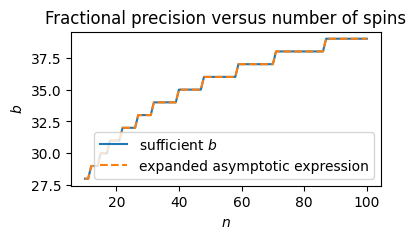

In [2]:
beta = 4
eps_discr = 1e-4

def fractional_bits(n: int, beta: float, eps: float) -> float:
    """Return the sufficient fractional-bit bound from the manuscript."""
    M = n * (n + 1) / 2
    Lambda = (2 / np.sqrt(np.pi)) * n**1.5
    return np.ceil(np.log2(2 * M * beta * Lambda / eps))

def asymptotic_fractional_bits(n: int, beta: float, eps: float) -> float:
    """Return the expanded asymptotic expression for the same bound."""
    return np.ceil(
        3.5 * np.log2(n)
        + np.log2(1 / eps)
        + np.log2(2 * beta / np.sqrt(np.pi))
        + np.log2(1 + 1 / n)
    )

ns = np.arange(10, 101)
plt.figure(figsize=(4, 2))
plt.plot(
    ns,
    [fractional_bits(n, beta, eps_discr) for n in ns],
    label="sufficient $b$",
)
plt.plot(
    ns,
    [asymptotic_fractional_bits(n, beta, eps_discr) for n in ns],
    linestyle="--",
    label="expanded asymptotic expression",
)
plt.title("Fractional precision versus number of spins")
plt.xlabel(r"$n$")
plt.ylabel(r"$b$")
plt.legend()
plt.show()


<a id="operation-error"></a>
## Operation error

Only the positive-energy branch of the Metropolis acceptance function must be approximated, since configurations with $\Delta H\leq0$ are accepted exactly. Let

$$
x=\frac{\Delta H}{\Lambda}\in[0,1],
$$

and define

$$
g(x)=\exp(-\beta\Lambda x).
$$

For the hybrid quantum Boltzmann coin, the same analysis applies to the square-root acceptance amplitude after replacing $\beta$ with $\beta/2$.

Let $\lambda=\beta\Lambda$. We approximate $g$ by a degree-$d$ Chebyshev polynomial $p_d$ on $[0,1]$. Mapping the domain to $[-1,1]$ with $t=2x-1$ gives $g(x)=e^{-\lambda x}=e^{-z}e^{-zt}$, where $z=\lambda/2$. The corresponding Chebyshev expansion is

$$
g(x)
=
e^{-\lambda x}
=
e^{-z}
\left[
I_0(z)
+
2\sum_{k=1}^{\infty}(-1)^kI_k(z)T_k(t)
\right].
$$


The truncation error is controlled by the tail of the coefficients $2e^{-z}I_k(z)$. These coefficients have two useful decay regimes:

* **Factorial regime.** When $z\lesssim2\log(\varepsilon_{\mathrm{op}}^{-1})$, the degree required to reach the target error lies in the far tail of the Bessel coefficients, where the decay is approximately factorial. A conservative choice is $d=O(\log(\varepsilon_{\mathrm{op}}^{-1}))$. This bound is safe but can be pessimistic.

* **Gaussian regime.** When $z$ is sufficiently large and the relevant coefficients satisfy $k\ll z$, the coefficients decay approximately as a Gaussian in $k/\sqrt z$. The required degree then scales as $d\sim\sqrt{z\log(\varepsilon_{\mathrm{op}}^{-1})}=\sqrt{\lambda\log(\varepsilon_{\mathrm{op}}^{-1})/2}$. Up to constants, this gives $d=O(\sqrt{\lambda\log(\varepsilon_{\mathrm{op}}^{-1})})$.

The transition between the two regimes is not sharp. The following code compares the exact coefficient decay with the two asymptotic estimates. A conservative heuristic for the untruncated positive branch is

$$
d
\sim
\sqrt{\beta\Lambda\log(\varepsilon_{\mathrm{op}}^{-1})}
+
\log(\varepsilon_{\mathrm{op}}^{-1}).
$$


In [3]:
def compare_decay_regimes(
    lam: float = 1.0,
    max_k: int = 25,
    eps: float = 1e-16,
    dps: int = 120,
) -> None:
    """Compare exact Chebyshev coefficient decay with factorial and Gaussian estimates."""
    mp.mp.dps = dps
    lam, eps = mp.mpf(lam), mp.mpf(eps)
    z = lam / 2

    coeff = lambda k: 2 * mp.exp(-z) * mp.besseli(k, z)
    fact = lambda k: 2 * mp.exp(-z) * (z / 2) ** k / mp.factorial(k)
    gauss = lambda k: 2 / mp.sqrt(2 * mp.pi * z) * mp.exp(-k**2 / (2 * z))
    fmt = lambda x: f"{float(mp.mpf(x)):.5e}"

    def tail(d: int) -> mp.mpf:
        """Return the Chebyshev tail after degree d."""
        total = mp.mpf(0)
        for k in range(d + 1, 100000):
            ck = coeff(k)
            total += ck
            if k > d + 20 and ck < eps * mp.mpf("1e-8"):
                break
        return total

    d_fact = int(mp.ceil(2 * mp.log(2 / eps)))
    d_gauss = int(mp.ceil(mp.sqrt(lam * mp.log(1 / eps))))
    z_cut = 2 * mp.log(1 / eps)

    print(f"lambda={fmt(lam)}  z={fmt(z)}  eps={fmt(eps)}")
    print("-" * 55)
    print(f"{'k':>2} | {'|c_k|':>11} | {'factorial':>11} | {'Gaussian':>11} | best")
    print("-" * 55)

    for k in range(1, max_k + 1):
        ck, fk, gk = coeff(k), fact(k), gauss(k)
        best = "factorial" if abs(ck - fk) < abs(ck - gk) else "Gaussian"
        print(f"{k:2d} | {fmt(ck):>11} | {fmt(fk):>11} | {fmt(gk):>11} | {best}")

    print("-" * 55)
    regime = "Gaussian" if z > z_cut else "factorial"
    sign = ">" if z > z_cut else "<="
    print(f"rule: z={fmt(z)} {sign} {fmt(z_cut)} -> {regime}")
    print("-" * 55)

    for name, d in [("factorial", d_fact), ("Gaussian", d_gauss)]:
        err = tail(d)
        status = "ok" if err <= eps else "fail"
        print(f"{name:9s}: d={d:3d}, tail={fmt(err)} ({status})")

compare_decay_regimes(lam=100.0, max_k=20, eps=1e-8)


lambda=1.00000e+02  z=5.00000e+01  eps=1.00000e-08
-------------------------------------------------------
 k |       |c_k| |   factorial |    Gaussian | best
-------------------------------------------------------
 1 | 1.11986e-01 | 9.64375e-21 | 1.11715e-01 | Gaussian
 2 | 1.08644e-01 | 1.20547e-19 | 1.08413e-01 | Gaussian
 3 | 1.03295e-01 | 1.00456e-18 | 1.03126e-01 | Gaussian
 4 | 9.62484e-02 | 6.27848e-18 | 9.61541e-02 | Gaussian
 5 | 8.78950e-02 | 3.13924e-17 | 8.78783e-02 | Gaussian
 6 | 7.86694e-02 | 1.30802e-16 | 7.87243e-02 | Gaussian
 7 | 6.90143e-02 | 4.67149e-16 | 6.91275e-02 | Gaussian
 8 | 5.93454e-02 | 1.45984e-15 | 5.94986e-02 | Gaussian
 9 | 5.00238e-02 | 4.05511e-15 | 5.01969e-02 | Gaussian
10 | 4.13369e-02 | 1.01378e-14 | 4.15107e-02 | Gaussian
11 | 3.34891e-02 | 2.30404e-14 | 3.36480e-02 | Gaussian
12 | 2.66017e-02 | 4.80009e-14 | 2.67344e-02 | Gaussian
13 | 2.07202e-02 | 9.23094e-14 | 2.08208e-02 | Gaussian
14 | 1.58271e-02 | 1.64838e-13 | 1.58942e-02 | Gaussian
1

The approximated function and its pointwise error can be plotted explicitly:


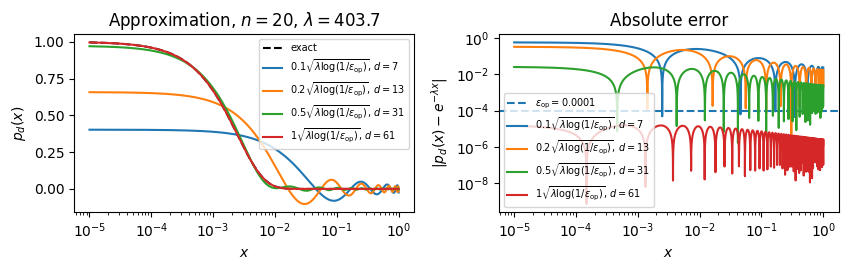

In [4]:
beta, eps_op, n0 = 4, 1e-4, 20
fractions = [1 / 10, 1 / 5, 1 / 2, 1]

Lambda = lambda n: 2 / np.sqrt(np.pi) * n**1.5

def approximate_exp(lam: float, d: int, x: np.ndarray) -> np.ndarray:
    """Return the degree-d Chebyshev truncation of exp(-lam*x) on [0, 1]."""
    k = np.arange(d + 1)
    coefficients = 2 * (-1) ** k * ive(k, lam / 2)
    coefficients[0] /= 2
    return chebval(2 * x - 1, coefficients)

lam = beta * Lambda(n0)
base_degree = np.sqrt(lam * np.log(1 / eps_op))

x = np.geomspace(1e-5, 1, 8000)
exact = np.exp(-lam * x)

fig, ax = plt.subplots(1, 2, figsize=(8.5, 2.8))

ax[0].plot(x, exact, "k--", label="exact")
ax[1].axhline(eps_op, linestyle="--", label=fr"$\varepsilon_{{\mathrm{{op}}}}={eps_op}$")

for fraction in fractions:
    d = int(np.ceil(fraction * base_degree))
    approximation = approximate_exp(lam, d, x)
    label = fr"${fraction:g}\sqrt{{\lambda\log(1/\varepsilon_{{\mathrm{{op}}}})}}$, $d={d}$"
    ax[0].plot(x, approximation, label=label)
    ax[1].plot(x, np.abs(approximation - exact), label=label)

for axis in ax:
    axis.set_xscale("log")
    axis.set_xlabel(r"$x$")
    axis.legend(fontsize=7)

ax[0].set(
    title=fr"Approximation, $n={n0}$, $\lambda={lam:.1f}$",
    ylabel=r"$p_d(x)$",
)
ax[1].set(
    title="Absolute error",
    ylabel=r"$|p_d(x)-e^{-\lambda x}|$",
    yscale="log",
)

plt.tight_layout()
plt.show()


<a id="cutoff-approximation"></a>
## Cutoff approximation

A lower-degree approximation is obtained by truncating the exponentially small tail.

Split the operation-error budget as $\varepsilon_{\mathrm{op}}=\varepsilon_{\mathrm{tail}}+\varepsilon_{\mathrm{poly}}$ and define

$$
\tau
=
\min\left\{
1,
\frac{\log(\varepsilon_{\mathrm{tail}}^{-1})}{\beta\Lambda}
\right\}.
$$

For $x>\tau$, the exact function satisfies $g(x)=e^{-\beta\Lambda x}\leq\varepsilon_{\mathrm{tail}}$ and can therefore be replaced by zero. We approximate the cutoff function

$$
\widetilde g(x)
=
\begin{cases}
e^{-\beta\Lambda x}, & 0\leq x\leq\tau,\\
0, & x>\tau.
\end{cases}
$$

The discarded tail contributes at most $\varepsilon_{\mathrm{tail}}$. Defining $u=\beta\Lambda x$, the polynomial approximation is restricted to

$$
0
\leq
u
\leq
U
=
\min\left\{
\beta\Lambda,
\log(\varepsilon_{\mathrm{tail}}^{-1})
\right\}.
$$

The polynomial therefore approximates $e^{-u}$ on an interval whose length no longer grows with $\beta\Lambda$ once the cutoff is active. Numerically, the required degree is well described by

$$
d
\approx
\log_2(\varepsilon_{\mathrm{poly}}^{-1}).
$$


In [5]:
def compare_cutoff_approx(
    lam: float = 100.0,
    max_k: int = 25,
    eps: float = 1e-8,
    tail_fraction: float = 0.5,
    dps: int = 120,
) -> None:
    """Compare the cutoff approximation error with the exact Chebyshev tail."""
    mp.mp.dps = dps
    lam = mp.mpf(lam)
    eps = mp.mpf(eps)
    tail_fraction = mp.mpf(tail_fraction)

    if not 0 < tail_fraction < 1:
        raise ValueError("tail_fraction must be between 0 and 1")

    eps_tail = tail_fraction * eps
    eps_poly = (1 - tail_fraction) * eps
    u_cut = mp.log(1 / eps_tail)
    U = min(lam, u_cut)
    z = U / 2

    coeff = lambda k: 2 * mp.exp(-z) * mp.besseli(k, z)
    fmt = lambda x: f"{float(mp.mpf(x)):.5e}"

    def tail(d: int) -> mp.mpf:
        """Return the Chebyshev tail after degree d."""
        total = mp.mpf(0)
        for k in range(d + 1, 100000):
            ck = coeff(k)
            total += ck
            if k > d + 20 and ck < eps_poly * mp.mpf("1e-8"):
                break
        return total

    def minimum_degree() -> int:
        """Return the smallest degree whose polynomial tail is below eps_poly."""
        d = 0
        while tail(d) > eps_poly:
            d += 1
        return d

    d_rule = int(mp.ceil(mp.log(1 / eps_poly, 2)))
    d_min = minimum_degree()
    cutoff_error = eps_tail if lam > u_cut else mp.mpf(0)

    print(f"lambda={fmt(lam)}  u_cut={fmt(u_cut)}  U={fmt(U)}  z={fmt(z)}")
    print(f"eps={fmt(eps)}  eps_tail={fmt(eps_tail)}  eps_poly={fmt(eps_poly)}")
    print("-" * 31)
    print(f"{'k':>2} | {'|c_k|':>11}")
    print("-" * 31)

    for k in range(1, max_k + 1):
        print(f"{k:2d} | {fmt(coeff(k)):>11}")

    print("-" * 31)
    print(f"cutoff tail <= {fmt(cutoff_error)}")
    print("-" * 31)

    for name, d in [("rule", d_rule), ("minimum", d_min)]:
        polynomial_error = tail(d)
        total_error = cutoff_error + polynomial_error
        status = "ok" if total_error <= eps else "fail"
        print(
            f"{name:7s}: d={d:3d}, poly={fmt(polynomial_error)}, "
            f"total={fmt(total_error)} ({status})"
        )

compare_cutoff_approx(lam=1000.0, max_k=20, eps=1e-4)


lambda=1.00000e+03  u_cut=9.90349e+00  U=9.90349e+00  z=4.95174e+00
eps=1.00000e-04  eps_tail=5.00000e-05  eps_poly=5.00000e-05
-------------------------------
 k |       |c_k|
-------------------------------
 1 | 3.29228e-01
 2 | 2.36011e-01
 3 | 1.38579e-01
 4 | 6.80951e-02
 5 | 2.85652e-02
 6 | 1.04080e-02
 7 | 3.34249e-03
 8 | 9.57850e-04
 9 | 2.47498e-04
10 | 5.81743e-05
11 | 1.25331e-05
12 | 2.49109e-06
13 | 4.59388e-07
14 | 7.89922e-08
15 | 1.27204e-08
16 | 1.92582e-09
17 | 2.75061e-10
18 | 3.71783e-11
19 | 4.76883e-12
20 | 5.81967e-13
-------------------------------
cutoff tail <= 5.00000e-05
-------------------------------
rule   : d= 15, poly=2.24349e-09, total=5.00022e-05 (ok)
minimum: d= 10, poly=1.55776e-05, total=6.55776e-05 (ok)


For the target total-variation error $\varepsilon=10^{-2}$ used in the paper, the allocation above gives $\varepsilon_{\mathrm{op}}=10^{-4}$. With the explicit cutoff construction, the polynomial degree is controlled by the approximation budget through $U=\min\{\beta\Lambda,\log(\varepsilon_{\mathrm{tail}}^{-1})\}$ rather than directly by $\beta$, $\Lambda$, or $n$ once the cutoff is active. In the tested regime, degree $d=12$ is sufficient to keep the operation error below the allocated budget.


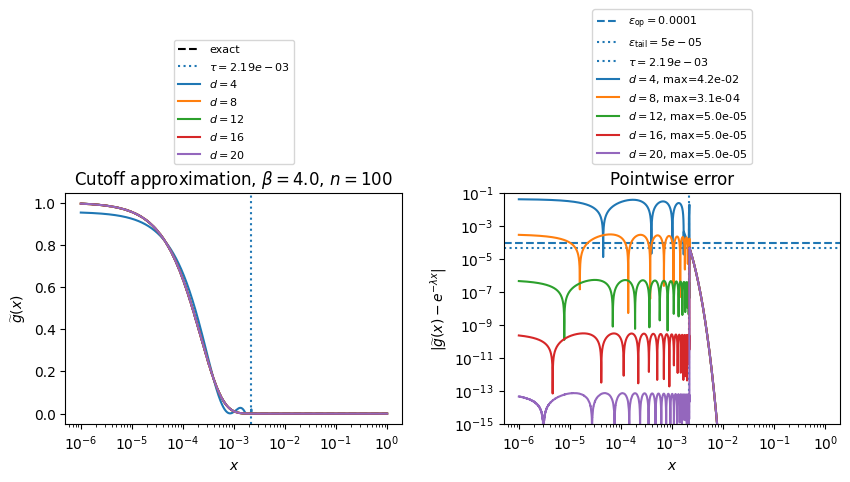

In [6]:
beta = 4
eps_op = 1e-4
n0 = 100

eps_tail = eps_poly = eps_op / 2
degrees = [4, 8, 12, 16, 20]
Lambda = lambda n: 2 / np.sqrt(np.pi) * n**1.5

def chebyshev_coefficients(U: float, d: int) -> np.ndarray:
    """Return Chebyshev coefficients for exp(-u) on u in [0, U]."""
    k = np.arange(d + 1)
    coefficients = 2 * (-1) ** k * ive(k, U / 2)
    coefficients[0] /= 2
    return coefficients

def cutoff_exp(x: np.ndarray, lam: float, u_cut: float, d: int) -> np.ndarray:
    """Return the cutoff Chebyshev approximation to exp(-lam*x)."""
    u = lam * np.maximum(x, 0)
    U = min(lam, u_cut)
    approximation = np.zeros_like(x)

    approximation[x <= 0] = 1

    if lam <= u_cut:
        active = x > 0
    else:
        active = (x > 0) & (u <= u_cut)

    approximation[active] = chebval(
        2 * u[active] / U - 1,
        chebyshev_coefficients(U, d),
    )
    return np.clip(approximation, 0, 1)

lam = beta * Lambda(n0)
u_cut = np.log(1 / eps_tail)
U = min(lam, u_cut)
x_cut = min(1, u_cut / lam)

x = np.geomspace(1e-6, 1, 8000)
exact = np.exp(-lam * x)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
fig.subplots_adjust(wspace=0.3)

ax[0].plot(x, exact, "k--", label="exact")
ax[1].axhline(
    eps_op,
    linestyle="--",
    label=fr"$\varepsilon_{{\mathrm{{op}}}}={eps_op}$",
)
ax[1].axhline(
    eps_tail,
    linestyle=":",
    label=fr"$\varepsilon_{{\mathrm{{tail}}}}={eps_tail}$",
)

if lam > u_cut:
    for axis in ax:
        axis.axvline(
            x_cut,
            linestyle=":",
            label=fr"$\tau={x_cut:.2e}$",
        )

for d in degrees:
    approximation = cutoff_exp(x, lam, u_cut, d)
    error = np.abs(approximation - exact)
    ax[0].plot(x, approximation, label=f"$d={d}$")
    ax[1].plot(x, error, label=f"$d={d}$, max={error.max():.1e}")

for axis in ax:
    axis.set_xscale("log")
    axis.set_xlabel(r"$x$")
    axis.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.1))

ax[0].set(
    title=fr"Cutoff approximation, $\beta={beta:.1f}$, $n={n0}$",
    ylabel=r"$\widetilde g(x)$",
)
ax[1].set(
    title="Pointwise error",
    ylabel=r"$|\widetilde g(x)-e^{-\lambda x}|$",
    yscale="log",
    ylim=(1e-15, 1e-1),
)

plt.show()
